# Part C — Sell-side credibility audit

This notebook sits after **Part A** (calibration and seed construction) and **Part B** (hedging experiments).

It directly addresses three issues that a sell-side quant, trader, or model validation team would care about:

1. **Are the results only simulated?**  
   Add a real-market anchor using realised SPX paths where data is available.

2. **Is calibration unstable or slow?**  
   Audit fit quality, parameter stability, failure rates, and runtime diagnostics.

3. **Is the learned hedge just trading too much?**  
   Test whether ML gains survive turnover, transaction costs, simple benchmark comparison, and stability checks.

The goal is not to magically turn a dissertation into a production trading system, because apparently reality still has opinions.  
The goal is to make the empirical design harder to dismiss.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE = Path("/mnt/data")

@dataclass
class PartCConfig:
    # Inputs from Part A
    episode_seeds_path: Path = BASE / "episode_seeds_v15_short_wide.csv"
    episode_fit_summary_path: Path = BASE / "episode_fit_summaries_v15_short_wide.csv"
    seed_selection_diag_path: Path = BASE / "episode_seed_selection_diagnostics_v15_short_wide.csv"

    # Inputs from Part B
    seed_results_path: Path = BASE / "part_b_v9_seed_results.csv"
    seed_results_raw_path: Path = BASE / "part_b_v9_seed_results_raw.csv"
    summary_results_path: Path = BASE / "part_b_v9_summary_results.csv"
    stability_results_path: Path = BASE / "part_b_v9_training_stability_results.csv"
    bootstrap_ci_path: Path = BASE / "part_b_v9_bootstrap_ci.csv"

    # Optional realised underlying data.
    # Add or rename as needed.
    candidate_spx_paths: tuple[Path, ...] = (
        BASE / "CRSP S&P 2010 – 2024.csv",
        BASE / "CRSP S&P 2010 - 2024.csv",
        BASE / "crsp_spx_2010_2024.csv",
        BASE / "spx_prices.csv",
        BASE / "spx_prices.parquet",
    )

    # Sell-side audit thresholds. These are deliberately conservative.
    max_learned_turnover_ratio_vs_bs: float = 1.50
    min_residual_pnl_improvement: float = 0.0
    max_variance_ratio_vs_bs: float = 1.00
    min_cvar_improvement: float = 0.0
    max_training_cv_abs: float = 0.50
    slow_calibration_quantile: float = 0.90

CFG_C = PartCConfig()
CFG_C


PartCConfig(episode_seeds_path=WindowsPath('/mnt/data/episode_seeds_v15_short_wide.csv'), episode_fit_summary_path=WindowsPath('/mnt/data/episode_fit_summaries_v15_short_wide.csv'), seed_selection_diag_path=WindowsPath('/mnt/data/episode_seed_selection_diagnostics_v15_short_wide.csv'), seed_results_path=WindowsPath('/mnt/data/part_b_v9_seed_results.csv'), seed_results_raw_path=WindowsPath('/mnt/data/part_b_v9_seed_results_raw.csv'), summary_results_path=WindowsPath('/mnt/data/part_b_v9_summary_results.csv'), stability_results_path=WindowsPath('/mnt/data/part_b_v9_training_stability_results.csv'), bootstrap_ci_path=WindowsPath('/mnt/data/part_b_v9_bootstrap_ci.csv'), candidate_spx_paths=(WindowsPath('/mnt/data/CRSP S&P 2010 – 2024.csv'), WindowsPath('/mnt/data/CRSP S&P 2010 - 2024.csv'), WindowsPath('/mnt/data/crsp_spx_2010_2024.csv'), WindowsPath('/mnt/data/spx_prices.csv'), WindowsPath('/mnt/data/spx_prices.parquet')), max_learned_turnover_ratio_vs_bs=1.5, min_residual_pnl_improvement

## 1. Load Part A and Part B outputs

This section loads outputs if they exist. If a file is missing, the notebook keeps going and tells you what cannot be audited yet. Groundbreaking stuff: error handling.


In [2]:
def load_optional_csv(path: Path, name: str) -> pd.DataFrame:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {name}: {path.name} | {df.shape[0]:,} rows × {df.shape[1]:,} cols")
        return df
    print(f"Missing {name}: {path}")
    return pd.DataFrame()

episode_seeds = load_optional_csv(CFG_C.episode_seeds_path, "Part A episode seeds")
fit_summary = load_optional_csv(CFG_C.episode_fit_summary_path, "Part A episode fit summary")
seed_diag = load_optional_csv(CFG_C.seed_selection_diag_path, "Part A seed selection diagnostics")

seed_results = load_optional_csv(CFG_C.seed_results_path, "Part B seed-level hedging results")
seed_results_raw = load_optional_csv(CFG_C.seed_results_raw_path, "Part B raw seed/run hedging results")
summary_results = load_optional_csv(CFG_C.summary_results_path, "Part B summary results")
stability_results = load_optional_csv(CFG_C.stability_results_path, "Part B training stability")
bootstrap_ci = load_optional_csv(CFG_C.bootstrap_ci_path, "Part B bootstrap confidence intervals")

for df in [episode_seeds, fit_summary, seed_results, seed_results_raw, summary_results, stability_results, bootstrap_ci]:
    if not df.empty and "trade_date" in df.columns:
        df["trade_date"] = pd.to_datetime(df["trade_date"], errors="coerce")


Loaded Part A episode seeds: episode_seeds_v15_short_wide.csv | 144 rows × 62 cols
Loaded Part A episode fit summary: episode_fit_summaries_v15_short_wide.csv | 384 rows × 11 cols
Loaded Part A seed selection diagnostics: episode_seed_selection_diagnostics_v15_short_wide.csv | 71,859 rows × 34 cols
Loaded Part B seed-level hedging results: part_b_v9_seed_results.csv | 32,256 rows × 29 cols
Loaded Part B raw seed/run hedging results: part_b_v9_seed_results_raw.csv | 69,120 rows × 21 cols
Loaded Part B summary results: part_b_v9_summary_results.csv | 2,016 rows × 29 cols
Loaded Part B training stability: part_b_v9_training_stability_results.csv | 576 rows × 20 cols
Loaded Part B bootstrap confidence intervals: part_b_v9_bootstrap_ci.csv | 2,688 rows × 13 cols


## 2. Real-market anchor: realised SPX path replay

This does **not** replace the simulated hedging experiment. It adds a sanity check using realised underlying paths.

Why this matters:

- simulated paths tell you what the model world implies;
- realised SPX paths tell you whether the hedge behaviour looks absurd when replayed through actual market moves;
- sell-side readers are less likely to file your work under “academic snow globe”.

This section uses available SPX/CRSP close data. It evaluates simple realised-path diagnostics for selected trades:
- terminal straddle payoff;
- unhedged terminal P&L proxy;
- Black-Scholes delta hedge proxy;
- realised hedge turnover.

If option marks across the life of the trade are available, you can extend this to full daily marked-to-market P&L. Without option panel marks, keep this honestly labelled as a **realised underlying path replay**, not a full historical backtest.


In [3]:
def find_existing_price_path(paths: tuple[Path, ...]) -> Path | None:
    for p in paths:
        if p.exists():
            return p
    return None

def load_spx_prices(cfg: PartCConfig) -> pd.DataFrame:
    path = find_existing_price_path(cfg.candidate_spx_paths)
    if path is None:
        print("No realised SPX/CRSP price file found. Real-path replay will be skipped.")
        print("Expected one of:")
        for p in cfg.candidate_spx_paths:
            print(" -", p)
        return pd.DataFrame()

    if path.suffix.lower() == ".parquet":
        px = pd.read_parquet(path)
    else:
        px = pd.read_csv(path)

    # Flexible column detection. Because every data vendor apparently hates standardisation.
    date_candidates = ["date", "caldt", "Date", "DATE", "trade_date"]
    price_candidates = ["close", "Close", "PRC", "spindx", "SPINDX", "price", "PX_LAST", "S"]

    date_col = next((c for c in date_candidates if c in px.columns), None)
    price_col = next((c for c in price_candidates if c in px.columns), None)

    if date_col is None or price_col is None:
        raise ValueError(f"Could not infer date/price columns from {path.name}. Columns: {list(px.columns)}")

    out = px[[date_col, price_col]].rename(columns={date_col: "date", price_col: "S"}).copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["S"] = pd.to_numeric(out["S"], errors="coerce").abs()
    out = out.dropna().sort_values("date").drop_duplicates("date")
    print(f"Loaded realised price file: {path.name} | {len(out):,} daily observations")
    return out

spx_prices = load_spx_prices(CFG_C)
spx_prices.head()


No realised SPX/CRSP price file found. Real-path replay will be skipped.
Expected one of:
 - \mnt\data\CRSP S&P 2010 – 2024.csv
 - \mnt\data\CRSP S&P 2010 - 2024.csv
 - \mnt\data\crsp_spx_2010_2024.csv
 - \mnt\data\spx_prices.csv
 - \mnt\data\spx_prices.parquet


""


In [4]:
def norm_cdf(x):
    x = np.asarray(x, dtype=float)
    return 0.5 * (1.0 + np.vectorize(math.erf)(x / math.sqrt(2.0)))

def bs_call_delta(S, K, r, q, tau, sigma):
    S = np.asarray(S, dtype=float)
    tau = np.maximum(np.asarray(tau, dtype=float), 1e-8)
    sigma = max(float(sigma), 1e-8)
    d1 = (np.log(np.maximum(S, 1e-12) / K) + (r - q + 0.5 * sigma * sigma) * tau) / (sigma * np.sqrt(tau))
    return np.exp(-q * tau) * norm_cdf(d1)

def bs_put_delta(S, K, r, q, tau, sigma):
    return bs_call_delta(S, K, r, q, tau, sigma) - np.exp(-q * np.maximum(tau, 1e-8))

def bs_straddle_delta(S, K, r, q, tau, sigma):
    return bs_call_delta(S, K, r, q, tau, sigma) + bs_put_delta(S, K, r, q, tau, sigma)

def infer_seed_columns(seeds: pd.DataFrame) -> dict:
    candidates = {
        "trade_date": ["trade_date", "date", "entry_date"],
        "expiry_date": ["expiry_date", "exdate", "expiration", "expiry"],
        "K": ["strike", "K", "strike_price"],
        "entry_price": ["straddle_entry_mid", "entry_straddle_mid", "straddle_mid", "premium"],
        "S0": ["S0", "spot", "underlying_price", "forward_price"],
        "T": ["T", "ttm", "time_to_maturity"],
        "dte": ["target_dte", "dte", "days_to_expiry"],
        "r": ["r", "rate"],
        "q": ["q", "dividend_yield"],
        "iv": ["entry_iv", "atm_iv", "impl_volatility", "iv"],
    }
    mapping = {}
    for key, cols in candidates.items():
        mapping[key] = next((c for c in cols if c in seeds.columns), None)
    return mapping

def realised_path_replay(seeds: pd.DataFrame, prices: pd.DataFrame, max_trades: int | None = None) -> pd.DataFrame:
    if seeds.empty or prices.empty:
        return pd.DataFrame()

    mp = infer_seed_columns(seeds)
    required = ["trade_date", "K", "entry_price"]
    missing = [k for k in required if mp[k] is None]
    if missing:
        print("Cannot run realised replay. Missing seed columns for:", missing)
        print("Detected mapping:", mp)
        return pd.DataFrame()

    x = seeds.copy()
    x["trade_date"] = pd.to_datetime(x[mp["trade_date"]], errors="coerce")
    if mp["expiry_date"]:
        x["expiry_date"] = pd.to_datetime(x[mp["expiry_date"]], errors="coerce")
    elif mp["dte"]:
        x["expiry_date"] = x["trade_date"] + pd.to_timedelta(pd.to_numeric(x[mp["dte"]], errors="coerce").round().astype("Int64"), unit="D")
    elif mp["T"]:
        x["expiry_date"] = x["trade_date"] + pd.to_timedelta((pd.to_numeric(x[mp["T"]], errors="coerce") * 365).round().astype("Int64"), unit="D")
    else:
        print("Cannot infer expiry date. Add `exdate`, `expiry_date`, `target_dte`, `dte`, or `T` to episode seeds.")
        return pd.DataFrame()

    x = x.dropna(subset=["trade_date", "expiry_date"]).sort_values("trade_date")
    if max_trades is not None:
        x = x.head(max_trades)

    rows = []
    prices = prices.sort_values("date")

    for _, row in x.iterrows():
        entry_date = row["trade_date"]
        expiry_date = row["expiry_date"]
        path = prices[(prices["date"] >= entry_date) & (prices["date"] <= expiry_date)].copy()
        if len(path) < 2:
            continue

        K = float(row[mp["K"]])
        entry_price = float(row[mp["entry_price"]])
        r = float(row[mp["r"]]) if mp["r"] else 0.0
        q = float(row[mp["q"]]) if mp["q"] else 0.0
        sigma = float(row[mp["iv"]]) if mp["iv"] else 0.20

        S = path["S"].to_numpy(float)
        dates = path["date"].to_numpy()
        S0, ST = float(S[0]), float(S[-1])
        payoff = max(ST - K, 0.0) + max(K - ST, 0.0)
        unhedged_pnl = payoff - entry_price

        n = len(S)
        taus = np.maximum((expiry_date - path["date"]).dt.days.to_numpy(float) / 365.0, 1e-8)
        deltas = bs_straddle_delta(S[:-1], K, r, q, taus[:-1], sigma)
        trades = np.diff(np.r_[0.0, deltas])
        turnover = np.sum(np.abs(trades))

        # Self-financing hedge proxy: buy/sell underlying to target straddle delta.
        # For a long straddle, hedge inventory is -delta.
        hedge_inventory = -deltas
        hedge_trades = np.diff(np.r_[0.0, hedge_inventory])
        cash = -entry_price - np.sum(hedge_trades * S[:-1])
        hedged_pnl_no_tc = cash + hedge_inventory[-1] * ST + payoff

        rows.append({
            "seed_id": row.get("seed_id", np.nan),
            "experiment_id": row.get("experiment_id", "unknown"),
            "maturity_bucket": row.get("maturity_bucket", "unknown"),
            "entry_date": entry_date,
            "expiry_date": expiry_date,
            "n_realised_obs": n,
            "S0_realised": S0,
            "ST_realised": ST,
            "K": K,
            "entry_price": entry_price,
            "entry_iv": sigma,
            "realised_return": ST / S0 - 1.0,
            "terminal_payoff": payoff,
            "unhedged_realised_pnl": unhedged_pnl,
            "bs_delta_realised_pnl_no_tc": hedged_pnl_no_tc,
            "bs_delta_realised_turnover": turnover,
        })

    return pd.DataFrame(rows)

realised_replay = realised_path_replay(episode_seeds, spx_prices)
if realised_replay.empty:
    print("Realised replay not available yet.")
else:
    display(realised_replay.head())
    display(realised_replay[[
        "unhedged_realised_pnl",
        "bs_delta_realised_pnl_no_tc",
        "bs_delta_realised_turnover",
        "realised_return"
    ]].describe().T)


Realised replay not available yet.


In [5]:
if not realised_replay.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    realised_replay[["unhedged_realised_pnl", "bs_delta_realised_pnl_no_tc"]].plot(kind="box", ax=ax)
    ax.set_title("Realised underlying path replay: terminal P&L proxy")
    ax.set_ylabel("P&L")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    realised_replay["bs_delta_realised_turnover"].hist(bins=30, ax=ax)
    ax.set_title("Realised underlying path replay: BS delta hedge turnover")
    ax.set_xlabel("Total absolute hedge turnover")
    fig.tight_layout()
    plt.show()


### Real-market anchor interpretation

Use this section in the dissertation carefully:

> To reduce reliance on simulated paths alone, I add a realised-underlying-path replay using historical SPX closes. This does not constitute a full marked-to-market historical backtest, since option marks over the full life of each straddle are not used. However, it provides an external diagnostic of whether the selected trades and hedge rules behave plausibly on realised market paths, especially in terms of terminal exposure and hedge turnover.

That wording is boring, precise, and therefore less likely to be murdered by a supervisor.


## 3. Calibration stability and speed audit

This section checks whether the calibration stage is too fragile or slow to be plausible.

The sell-side question is not only:

> “Does lifted Heston fit better?”

It is also:

> “Does it fit reliably, quickly, and without parameter values bouncing around like a caffeinated squirrel?”


In [6]:
def numeric_cols(df: pd.DataFrame) -> list[str]:
    return list(df.select_dtypes(include=[np.number]).columns)

def find_cols(df: pd.DataFrame, patterns: list[str]) -> list[str]:
    cols = []
    for c in df.columns:
        lc = c.lower()
        if any(p.lower() in lc for p in patterns):
            cols.append(c)
    return cols

def calibration_audit(fit: pd.DataFrame, seeds: pd.DataFrame) -> dict[str, pd.DataFrame]:
    if fit.empty:
        print("No fit summary found. Run Part A first.")
        return {}

    out = {}
    df = fit.copy()

    # Try to identify model/world and date columns flexibly.
    model_cols = find_cols(df, ["model", "world"])
    date_cols = find_cols(df, ["date", "trade_date", "calibration_date"])
    error_cols = find_cols(df, ["rmse", "mae", "error", "loss", "objective", "iv"])
    runtime_cols = find_cols(df, ["runtime", "seconds", "elapsed", "time"])
    success_cols = [c for c in df.columns if c.lower() in {"success", "converged", "is_valid", "valid"}]

    print("Detected model/world columns:", model_cols)
    print("Detected date columns:", date_cols)
    print("Detected error/loss columns:", error_cols)
    print("Detected runtime columns:", runtime_cols)
    print("Detected success columns:", success_cols)

    # Summary of numeric diagnostics by model/world if available.
    group_cols = []
    if model_cols:
        group_cols.append(model_cols[0])
    if group_cols:
        useful_numeric = [c for c in numeric_cols(df) if c in error_cols + runtime_cols or any(k in c.lower() for k in ["rmse", "mae", "runtime", "error", "loss"])]
        if useful_numeric:
            out["fit_quality_by_model"] = df.groupby(group_cols)[useful_numeric].agg(["count", "mean", "median", "std", "min", "max"])
            display(out["fit_quality_by_model"])

    # Runtime flags.
    if runtime_cols:
        rt = runtime_cols[0]
        threshold = df[rt].quantile(CFG_C.slow_calibration_quantile)
        df["slow_calibration_flag"] = df[rt] >= threshold
        out["slow_calibrations"] = df.loc[df["slow_calibration_flag"]].sort_values(rt, ascending=False)
        print(f"Slow calibration threshold ({CFG_C.slow_calibration_quantile:.0%} quantile): {threshold:.3f}")
        display(out["slow_calibrations"].head(20))

    # Success/failure rates.
    if success_cols:
        sc = success_cols[0]
        tmp = df.copy()
        tmp[sc] = tmp[sc].astype(str).str.lower().isin(["true", "1", "yes", "y", "success", "converged"])
        if group_cols:
            out["success_rate"] = tmp.groupby(group_cols)[sc].agg(["count", "mean"])
        else:
            out["success_rate"] = tmp[sc].agg(["count", "mean"]).to_frame().T
        display(out["success_rate"])

    # Parameter jump audit.
    param_cols = [
        c for c in numeric_cols(df)
        if any(k in c.lower() for k in ["kappa", "theta", "sigma", "rho", "v0", "h_", "lambda", "nu", "factor"])
        and not any(bad in c.lower() for bad in ["error", "rmse", "runtime", "time"])
    ]

    if date_cols and param_cols:
        date_col = date_cols[0]
        tmp = df.copy()
        tmp[date_col] = pd.to_datetime(tmp[date_col], errors="coerce")
        tmp = tmp.sort_values(group_cols + [date_col] if group_cols else [date_col])
        jump_rows = []
        for key, g in tmp.groupby(group_cols) if group_cols else [(("all",), tmp)]:
            for p in param_cols:
                s = pd.to_numeric(g[p], errors="coerce")
                jump = s.diff().abs()
                denom = s.abs().shift(1).replace(0, np.nan)
                rel_jump = jump / denom
                jump_rows.append({
                    "group": key if isinstance(key, str) else " | ".join(map(str, key if isinstance(key, tuple) else [key])),
                    "parameter": p,
                    "median_abs_jump": float(jump.median(skipna=True)),
                    "p90_rel_jump": float(rel_jump.quantile(0.90)),
                    "max_rel_jump": float(rel_jump.max(skipna=True)),
                })
        out["parameter_jump_audit"] = pd.DataFrame(jump_rows).sort_values("p90_rel_jump", ascending=False)
        display(out["parameter_jump_audit"].head(30))

    return out

calibration_audit_outputs = calibration_audit(fit_summary, episode_seeds)


Detected model/world columns: ['model']
Detected date columns: ['trade_date']
Detected error/loss columns: ['fit_median_abs_iv_error', 'fit_mean_abs_iv_error', 'fit_median_abs_rel_price_error', 'fit_mean_abs_rel_price_error']
Detected runtime columns: []
Detected success columns: []


fit_median_abs_iv_error                                                   fit_mean_abs_iv_error                                          \
                               count      mean    median       std       min       max                 count      mean    median       std       min   
model                                                                                                                                                  
Heston                           192  0.001992  0.001836  0.000927  0.000438  0.004813                   192  0.002155  0.002214  0.000790  0.000860   
LiftedHeston                     192  0.004120  0.003444  0.002138  0.001573  0.012777                   192  0.004433  0.003737  0.001844  0.001854   

                       fit_median_abs_rel_price_error                                                   fit_mean_abs_rel_price_error                      \
                   max                          count      mean    median       std       min       max                        count      mean    median   
model                                                                                                                                                      
Heston        0.004284                            192  0.013353  0.012366  0.006066  0.003145  0.027012                          192  0.014505  0.014333   
LiftedHeston  0.013132                            192  0.027852  0.022670  0.014894  0.009854  0.077435                          192  0.029999  0.025946   

                                            
                   std       min       max  
model                                       
Heston        0.005366  0.005014  0.030809  
LiftedHeston  0.013223  0.011323  0.074626

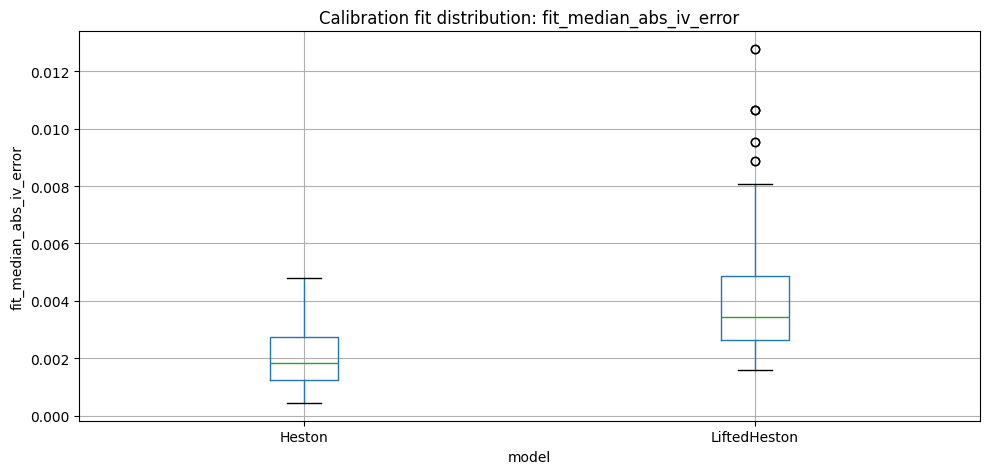

In [7]:
if not fit_summary.empty:
    runtime_cols = find_cols(fit_summary, ["runtime", "seconds", "elapsed", "time"])
    model_cols = find_cols(fit_summary, ["model", "world"])
    error_cols = find_cols(fit_summary, ["rmse", "mae", "error", "loss", "objective"])

    if runtime_cols:
        rt = runtime_cols[0]
        fig, ax = plt.subplots(figsize=(10, 5))
        if model_cols:
            for name, g in fit_summary.groupby(model_cols[0]):
                pd.to_numeric(g[rt], errors="coerce").dropna().hist(alpha=0.5, bins=30, ax=ax, label=str(name))
            ax.legend()
        else:
            pd.to_numeric(fit_summary[rt], errors="coerce").dropna().hist(bins=30, ax=ax)
        ax.set_title("Calibration runtime distribution")
        ax.set_xlabel(rt)
        fig.tight_layout()
        plt.show()

    if error_cols:
        err = error_cols[0]
        fig, ax = plt.subplots(figsize=(10, 5))
        if model_cols:
            fit_summary.boxplot(column=err, by=model_cols[0], ax=ax)
            plt.suptitle("")
        else:
            pd.to_numeric(fit_summary[err], errors="coerce").dropna().hist(bins=30, ax=ax)
        ax.set_title(f"Calibration fit distribution: {err}")
        ax.set_ylabel(err)
        fig.tight_layout()
        plt.show()


### Calibration audit interpretation

Use this to strengthen the methods chapter:

> Calibration quality is assessed not only by average fit error, but also by convergence behaviour, runtime, and parameter stability across dates. This is important because a volatility model that fits only intermittently, or requires excessive calibration time, is unlikely to be useful for practical hedging.

The brutal little truth: a slightly worse model that calibrates reliably can be more useful than a beautiful model that collapses every third Wednesday.


## 4. Turnover discipline: is the learned hedge just trading too much?

This section tests whether the machine-learning hedge is producing genuine risk-adjusted improvement or simply buying performance with excessive trading.

The core checks are:

1. learned hedge vs Black-Scholes delta;
2. learned hedge vs no-trade-band benchmark;
3. residual P&L improvement per unit turnover;
4. variance and CVaR improvement;
5. stability across repeated training runs.

If the learned hedge improves mean P&L but explodes turnover, that is not alpha. That is a brokerage donation scheme.


In [8]:
def prepare_test_results(seed_results: pd.DataFrame) -> pd.DataFrame:
    if seed_results.empty:
        print("No seed-level hedging results found. Run Part B first.")
        return pd.DataFrame()
    df = seed_results.copy()
    if "split" in df.columns:
        df = df[df["split"].astype(str).str.lower().eq("test")].copy()
    return df

def aggregate_for_policy_audit(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    group_cols = [
        c for c in [
            "scenario_id", "tc_bps", "hedge_steps_per_day",
            "experiment_id", "trade_experiment", "calibration_window_mode",
            "world", "policy"
        ] if c in df.columns
    ]

    metric_cols = [
        c for c in [
            "mean_residual_pnl_vs_unhedged", "mean_centered_pnl_vs_world_edge",
            "mean_pnl", "pnl_variance", "pnl_std", "cvar_5", "mean_turnover"
        ] if c in df.columns
    ]

    if not group_cols or not metric_cols:
        print("Missing expected grouping or metric columns.")
        print("Columns:", list(df.columns))
        return pd.DataFrame()

    return df.groupby(group_cols, dropna=False)[metric_cols].mean().reset_index()

test_seed_results = prepare_test_results(seed_results)
policy_summary = aggregate_for_policy_audit(test_seed_results)

if policy_summary.empty:
    print("Policy audit unavailable.")
else:
    display(policy_summary.head(20))


,scenario_id,tc_bps,hedge_steps_per_day,experiment_id,trade_experiment,calibration_window_mode,world,policy,mean_residual_pnl_vs_unhedged,mean_centered_pnl_vs_world_edge,mean_pnl,pnl_variance,pnl_std,cvar_5,mean_turnover
0,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,banded_fd_model_delta,2.329796,2.329802,-2.179304,64873.469791,239.840801,-309.016210,1.933345
1,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,bs_delta,1.625264,1.625270,-2.883836,146354.718142,360.328157,-453.775363,2.348732
2,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,fd_model_delta,2.233412,2.233418,-2.275687,65461.499791,240.830243,-308.894897,2.261941
3,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,learned_hedge,5.553422,5.553427,1.044322,5387.877547,72.137149,-135.151483,1.494967
4,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,learned_hedge_tail,1.816095,1.816100,-2.693005,3849.534218,61.269855,-108.895142,2.042723
5,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,state_vol_delta,4.125826,4.125832,-0.383274,129801.031860,341.772785,-433.186254,2.541356
6,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,unhedged,0.000000,0.000006,-4.509100,39435.613406,188.125852,-213.797157,0.000000
7,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,lifted_world,banded_fd_model_delta,-0.455188,-0.455186,-126.293187,129580.978108,348.922922,-303.460126,0.910199
8,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,lifted_world,bs_delta,1.613343,1.613345,-124.224656,201651.423747,431.453361,-439.582288,0.709183
9,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,lifted_world,fd_model_delta,-0.883995,-0.883993,-126.721994,129867.030003,349.304071,-303.557744,1.151547


In [9]:
def compare_policy_to_benchmark(summary: pd.DataFrame, candidate: str, benchmark: str) -> pd.DataFrame:
    if summary.empty:
        return pd.DataFrame()
    if "policy" not in summary.columns:
        return pd.DataFrame()

    id_cols = [c for c in summary.columns if c not in {
        "policy", "mean_residual_pnl_vs_unhedged", "mean_centered_pnl_vs_world_edge",
        "mean_pnl", "pnl_variance", "pnl_std", "cvar_5", "mean_turnover"
    }]

    cand = summary[summary["policy"].eq(candidate)].copy()
    base = summary[summary["policy"].eq(benchmark)].copy()

    if cand.empty or base.empty:
        print(f"Missing candidate={candidate} or benchmark={benchmark}.")
        return pd.DataFrame()

    merged = cand.merge(base, on=id_cols, suffixes=("_candidate", "_benchmark"))
    if merged.empty:
        print(f"No matched rows for {candidate} vs {benchmark}.")
        return pd.DataFrame()

    # Improvements: higher residual pnl is better, lower variance is better, higher CVaR is better because it is less negative.
    if "mean_residual_pnl_vs_unhedged_candidate" in merged:
        merged["residual_pnl_improvement"] = (
            merged["mean_residual_pnl_vs_unhedged_candidate"] - merged["mean_residual_pnl_vs_unhedged_benchmark"]
        )
    if "pnl_variance_candidate" in merged:
        merged["variance_ratio"] = merged["pnl_variance_candidate"] / merged["pnl_variance_benchmark"].replace(0, np.nan)
    if "cvar_5_candidate" in merged:
        merged["cvar_improvement"] = merged["cvar_5_candidate"] - merged["cvar_5_benchmark"]
    if "mean_turnover_candidate" in merged:
        merged["turnover_ratio"] = merged["mean_turnover_candidate"] / merged["mean_turnover_benchmark"].replace(0, np.nan)

    if {"residual_pnl_improvement", "turnover_ratio"}.issubset(merged.columns):
        merged["pnl_improvement_per_extra_turnover"] = merged["residual_pnl_improvement"] / (
            merged["mean_turnover_candidate"] - merged["mean_turnover_benchmark"]
        ).replace(0, np.nan)

    return merged

learned_vs_bs = compare_policy_to_benchmark(policy_summary, "learned_hedge", "bs_delta")
learned_tail_vs_bs = compare_policy_to_benchmark(policy_summary, "learned_hedge_tail", "bs_delta")
learned_vs_band = compare_policy_to_benchmark(policy_summary, "learned_hedge", "banded_fd_model_delta")
learned_tail_vs_band = compare_policy_to_benchmark(policy_summary, "learned_hedge_tail", "banded_fd_model_delta")

print("learned_hedge vs bs_delta")
display(learned_vs_bs.head(20))
print("learned_hedge_tail vs bs_delta")
display(learned_tail_vs_bs.head(20))


learned_hedge vs bs_delta


,scenario_id,tc_bps,hedge_steps_per_day,experiment_id,trade_experiment,calibration_window_mode,world,policy_candidate,mean_residual_pnl_vs_unhedged_candidate,mean_centered_pnl_vs_world_edge_candidate,mean_pnl_candidate,pnl_variance_candidate,pnl_std_candidate,cvar_5_candidate,mean_turnover_candidate,policy_benchmark,mean_residual_pnl_vs_unhedged_benchmark,mean_centered_pnl_vs_world_edge_benchmark,mean_pnl_benchmark,pnl_variance_benchmark,pnl_std_benchmark,cvar_5_benchmark,mean_turnover_benchmark,residual_pnl_improvement,variance_ratio,cvar_improvement,turnover_ratio,pnl_improvement_per_extra_turnover
0,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,learned_hedge,5.553422,5.553427,1.044322,5387.877547,72.137149,-135.151483,1.494967,bs_delta,1.625264,1.625270,-2.883836,146354.718142,360.328157,-453.775363,2.348732,3.928157,0.036814,318.623880,0.636500,-4.600982
1,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,lifted_world,learned_hedge,21.387823,21.387826,-104.450175,29538.635920,162.895874,-207.978714,1.191567,bs_delta,1.613343,1.613345,-124.224656,201651.423747,431.453361,-439.582288,0.709183,19.774481,0.146484,231.603574,1.680197,40.993251
2,tc0p25_freq0p5,0.25,0.5,baseline_wide,baseline,wide,heston_world,learned_hedge,5.031285,5.031283,6.131110,10787.724408,96.914183,-149.867573,1.593133,bs_delta,1.702401,1.702399,2.802226,149479.005382,364.206707,-489.882161,2.312531,3.328884,0.072169,340.014588,0.688913,-4.627318
3,tc0p25_freq0p5,0.25,0.5,baseline_wide,baseline,wide,lifted_world,learned_hedge,21.956133,21.956133,-91.835186,46392.187658,167.354235,-210.437502,1.198864,bs_delta,1.858958,1.858957,-111.932361,255275.025003,475.610974,-458.739342,0.852976,20.097176,0.181734,248.301840,1.405508,58.103064
4,tc0p25_freq0p5,0.25,0.5,short_end_local,short_end,local,heston_world,learned_hedge,0.952014,0.952015,2.106959,8490.558281,88.032307,-127.184317,0.837222,bs_delta,-0.402462,-0.402462,0.752482,63571.940489,240.650602,-330.729089,1.268972,1.354477,0.133558,203.544772,0.659764,-3.137177
5,tc0p25_freq0p5,0.25,0.5,short_end_local,short_end,local,lifted_world,learned_hedge,3.756763,3.756760,-20.769713,10919.222004,100.804989,-147.034732,1.094258,bs_delta,-0.033428,-0.033431,-24.559904,71940.740439,252.751560,-318.297073,1.010640,3.790191,0.151781,171.262341,1.082738,45.327099
6,tc0p25_freq1,0.25,1.0,baseline_local,baseline,local,heston_world,learned_hedge,5.126087,5.126092,0.616987,4465.419729,65.261788,-125.196983,2.008091,bs_delta,1.657076,1.657081,-2.852024,149816.922180,365.519258,-453.222715,3.358150,3.469011,0.029806,328.025732,0.597975,-2.569526
7,tc0p25_freq1,0.25,1.0,baseline_local,baseline,local,lifted_world,learned_hedge,21.545286,21.545289,-104.292712,28724.797604,160.416061,-206.359997,1.334851,bs_delta,1.598979,1.598981,-124.239019,208234.571864,438.909794,-450.009127,0.951888,19.946307,0.137944,243.649131,1.402319,52.084171
8,tc0p25_freq1,0.25,1.0,baseline_wide,baseline,wide,heston_world,learned_hedge,4.797333,4.797331,5.897157,9548.286241,89.766269,-141.069038,2.149007,bs_delta,1.452069,1.452067,2.551893,153164.751307,369.736126,-494.458636,3.316189,3.345264,0.062340,353.389598,0.648035,-2.866104
9,tc0p25_freq1,0.25,1.0,baseline_wide,baseline,wide,lifted_world,learned_hedge,22.085238,22.085237,-91.706081,44449.982313,162.879818,-207.317865,1.353606,bs_delta,1.609078,1.609078,-112.182241,265431.806131,485.284555,-460.944177,1.154755,20.476160,0.167463,253.626312,1.172202,102.972160


learned_hedge_tail vs bs_delta


,scenario_id,tc_bps,hedge_steps_per_day,experiment_id,trade_experiment,calibration_window_mode,world,policy_candidate,mean_residual_pnl_vs_unhedged_candidate,mean_centered_pnl_vs_world_edge_candidate,mean_pnl_candidate,pnl_variance_candidate,pnl_std_candidate,cvar_5_candidate,mean_turnover_candidate,policy_benchmark,mean_residual_pnl_vs_unhedged_benchmark,mean_centered_pnl_vs_world_edge_benchmark,mean_pnl_benchmark,pnl_variance_benchmark,pnl_std_benchmark,cvar_5_benchmark,mean_turnover_benchmark,residual_pnl_improvement,variance_ratio,cvar_improvement,turnover_ratio,pnl_improvement_per_extra_turnover
0,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,heston_world,learned_hedge_tail,1.816095,1.816100,-2.693005,3849.534218,61.269855,-108.895142,2.042723,bs_delta,1.625264,1.625270,-2.883836,146354.718142,360.328157,-453.775363,2.348732,0.190831,0.026303,344.880221,0.869713,-0.623612
1,tc0p25_freq0p5,0.25,0.5,baseline_local,baseline,local,lifted_world,learned_hedge_tail,19.999109,19.999111,-105.838889,29641.979536,163.063027,-203.962928,1.205574,bs_delta,1.613343,1.613345,-124.224656,201651.423747,431.453361,-439.582288,0.709183,18.385766,0.146996,235.619360,1.699949,37.038836
2,tc0p25_freq0p5,0.25,0.5,baseline_wide,baseline,wide,heston_world,learned_hedge_tail,1.648148,1.648146,2.747973,9552.035518,88.377292,-131.797318,2.038478,bs_delta,1.702401,1.702399,2.802226,149479.005382,364.206707,-489.882161,2.312531,-0.054253,0.063902,358.084843,0.881492,0.197965
3,tc0p25_freq0p5,0.25,0.5,baseline_wide,baseline,wide,lifted_world,learned_hedge_tail,20.569684,20.569683,-93.221635,51098.858092,170.228362,-203.314326,1.222058,bs_delta,1.858958,1.858957,-111.932361,255275.025003,475.610974,-458.739342,0.852976,18.710726,0.200172,255.425016,1.432700,50.695190
4,tc0p25_freq0p5,0.25,0.5,short_end_local,short_end,local,heston_world,learned_hedge_tail,0.588656,0.588656,1.743600,8060.603207,84.844174,-121.636850,1.006682,bs_delta,-0.402462,-0.402462,0.752482,63571.940489,240.650602,-330.729089,1.268972,0.991118,0.126795,209.092239,0.793305,-3.778710
5,tc0p25_freq0p5,0.25,0.5,short_end_local,short_end,local,lifted_world,learned_hedge_tail,3.161860,3.161857,-21.364616,9716.367905,95.379369,-136.191027,1.171217,bs_delta,-0.033428,-0.033431,-24.559904,71940.740439,252.751560,-318.297073,1.010640,3.195288,0.135061,182.106047,1.158887,19.898715
6,tc0p25_freq1,0.25,1.0,baseline_local,baseline,local,heston_world,learned_hedge_tail,1.248051,1.248056,-3.261049,3020.937498,53.973418,-96.559743,2.767336,bs_delta,1.657076,1.657081,-2.852024,149816.922180,365.519258,-453.222715,3.358150,-0.409025,0.020164,356.662972,0.824066,0.692307
7,tc0p25_freq1,0.25,1.0,baseline_local,baseline,local,lifted_world,learned_hedge_tail,20.047378,20.047380,-105.790620,28928.750426,160.968263,-202.887733,1.394012,bs_delta,1.598979,1.598981,-124.239019,208234.571864,438.909794,-450.009127,0.951888,18.448399,0.138924,247.121395,1.464471,41.726738
8,tc0p25_freq1,0.25,1.0,baseline_wide,baseline,wide,heston_world,learned_hedge_tail,1.266680,1.266678,2.366505,8425.179394,80.934974,-120.537433,2.764635,bs_delta,1.452069,1.452067,2.551893,153164.751307,369.736126,-494.458636,3.316189,-0.185388,0.055007,373.921204,0.833679,0.336121
9,tc0p25_freq1,0.25,1.0,baseline_wide,baseline,wide,lifted_world,learned_hedge_tail,20.488904,20.488904,-93.302414,47263.373021,164.114563,-200.583586,1.443933,bs_delta,1.609078,1.609078,-112.182241,265431.806131,485.284555,-460.944177,1.154755,18.879826,0.178062,260.360591,1.250424,65.287789


In [10]:
def sell_side_pass_fail(comp: pd.DataFrame, label: str, cfg: PartCConfig) -> pd.DataFrame:
    if comp.empty:
        return pd.DataFrame()

    x = comp.copy()
    x["passes_residual_pnl"] = x.get("residual_pnl_improvement", np.nan) > cfg.min_residual_pnl_improvement
    x["passes_turnover"] = x.get("turnover_ratio", np.inf) <= cfg.max_learned_turnover_ratio_vs_bs
    x["passes_variance"] = x.get("variance_ratio", np.inf) <= cfg.max_variance_ratio_vs_bs
    x["passes_cvar"] = x.get("cvar_improvement", np.nan) >= cfg.min_cvar_improvement

    pass_cols = ["passes_residual_pnl", "passes_turnover", "passes_variance", "passes_cvar"]
    x["sell_side_plausibility_score"] = x[pass_cols].sum(axis=1)
    x["audit_label"] = label

    display_cols = [
        "audit_label",
        *[c for c in ["scenario_id", "tc_bps", "hedge_steps_per_day", "experiment_id", "world"] if c in x.columns],
        "residual_pnl_improvement", "turnover_ratio", "variance_ratio", "cvar_improvement",
        "sell_side_plausibility_score",
        *pass_cols,
    ]
    return x[[c for c in display_cols if c in x.columns]].sort_values(
        ["sell_side_plausibility_score", "residual_pnl_improvement"], ascending=[False, False]
    )

audit_tables = []
for comp, label in [
    (learned_vs_bs, "learned_hedge_vs_bs_delta"),
    (learned_tail_vs_bs, "learned_hedge_tail_vs_bs_delta"),
    (learned_vs_band, "learned_hedge_vs_banded_model_delta"),
    (learned_tail_vs_band, "learned_hedge_tail_vs_banded_model_delta"),
]:
    tbl = sell_side_pass_fail(comp, label, CFG_C)
    if not tbl.empty:
        audit_tables.append(tbl)

sell_side_audit = pd.concat(audit_tables, ignore_index=True) if audit_tables else pd.DataFrame()
if sell_side_audit.empty:
    print("No pass/fail policy audit available.")
else:
    display(sell_side_audit.head(40))
    display(
        sell_side_audit.groupby("audit_label")["sell_side_plausibility_score"]
        .agg(["count", "mean", "median", "min", "max"])
        .reset_index()
    )


,audit_label,scenario_id,tc_bps,hedge_steps_per_day,experiment_id,world,residual_pnl_improvement,turnover_ratio,variance_ratio,cvar_improvement,sell_side_plausibility_score,passes_residual_pnl,passes_turnover,passes_variance,passes_cvar
0,learned_hedge_vs_bs_delta,tc2_freq4,2.00,4.0,baseline_wide,lifted_world,21.367645,0.910151,0.164780,267.560637,4,True,True,True,True
1,learned_hedge_vs_bs_delta,tc1_freq4,1.00,4.0,baseline_wide,lifted_world,21.251417,0.913182,0.165617,264.818863,4,True,True,True,True
2,learned_hedge_vs_bs_delta,tc0p5_freq4,0.50,4.0,baseline_wide,lifted_world,21.195814,0.914714,0.166039,263.451089,4,True,True,True,True
3,learned_hedge_vs_bs_delta,tc0p25_freq4,0.25,4.0,baseline_wide,lifted_world,21.168557,0.915490,0.166251,262.767698,4,True,True,True,True
4,learned_hedge_vs_bs_delta,tc0p25_freq2,0.25,2.0,baseline_wide,lifted_world,20.914611,1.024274,0.161466,258.863611,4,True,True,True,True
5,learned_hedge_vs_bs_delta,tc0p5_freq2,0.50,2.0,baseline_wide,lifted_world,20.912666,1.023614,0.161310,259.320726,4,True,True,True,True
6,learned_hedge_vs_bs_delta,tc1_freq2,1.00,2.0,baseline_wide,lifted_world,20.909574,1.022303,0.161000,260.235554,4,True,True,True,True
7,learned_hedge_vs_bs_delta,tc2_freq2,2.00,2.0,baseline_wide,lifted_world,20.906865,1.019733,0.160384,262.068430,4,True,True,True,True
8,learned_hedge_vs_bs_delta,tc0p25_freq1,0.25,1.0,baseline_wide,lifted_world,20.476160,1.172202,0.167463,253.626312,4,True,True,True,True
9,learned_hedge_vs_bs_delta,tc0p5_freq1,0.50,1.0,baseline_wide,lifted_world,20.451288,1.171687,0.167354,253.922340,4,True,True,True,True


,audit_label,count,mean,median,min,max
0,learned_hedge_tail_vs_banded_model_delta,96,3.666667,4.0,3,4
1,learned_hedge_tail_vs_bs_delta,96,3.812500,4.0,3,4
2,learned_hedge_vs_banded_model_delta,96,4.000000,4.0,4,4
3,learned_hedge_vs_bs_delta,96,3.958333,4.0,3,4


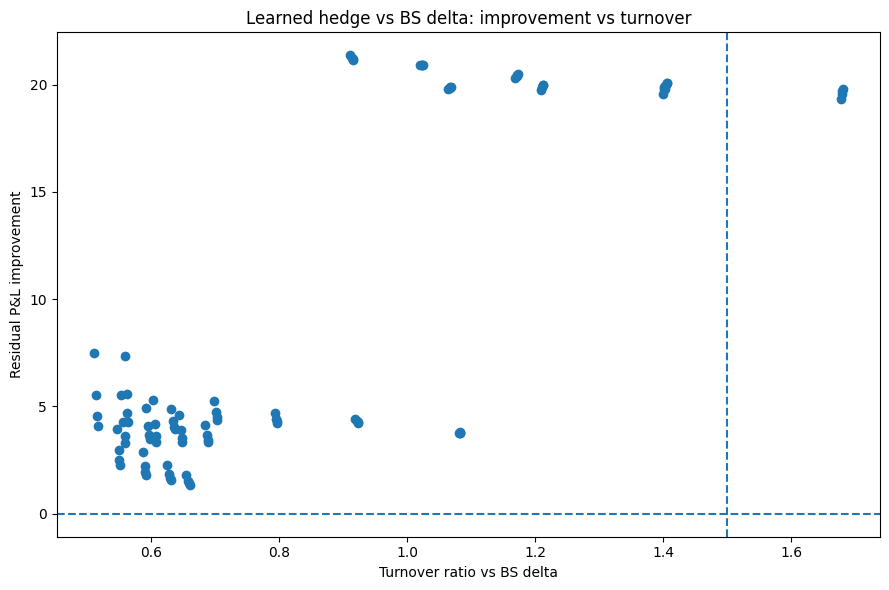

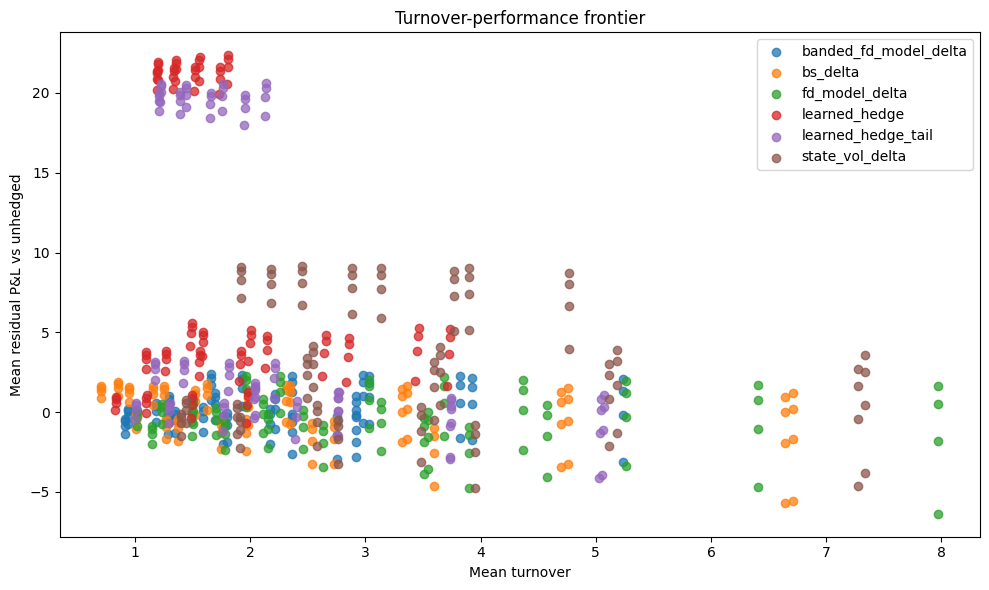

In [11]:
if not learned_vs_bs.empty and {"turnover_ratio", "residual_pnl_improvement"}.issubset(learned_vs_bs.columns):
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(learned_vs_bs["turnover_ratio"], learned_vs_bs["residual_pnl_improvement"])
    ax.axvline(CFG_C.max_learned_turnover_ratio_vs_bs, linestyle="--")
    ax.axhline(0.0, linestyle="--")
    ax.set_title("Learned hedge vs BS delta: improvement vs turnover")
    ax.set_xlabel("Turnover ratio vs BS delta")
    ax.set_ylabel("Residual P&L improvement")
    fig.tight_layout()
    plt.show()

if not policy_summary.empty and {"mean_turnover", "mean_residual_pnl_vs_unhedged", "policy"}.issubset(policy_summary.columns):
    plot_df = policy_summary.copy()
    # Keep the plot readable.
    keep = ["bs_delta", "state_vol_delta", "fd_model_delta", "banded_fd_model_delta", "learned_hedge", "learned_hedge_tail"]
    plot_df = plot_df[plot_df["policy"].isin(keep)]
    fig, ax = plt.subplots(figsize=(10, 6))
    for policy, g in plot_df.groupby("policy"):
        ax.scatter(g["mean_turnover"], g["mean_residual_pnl_vs_unhedged"], label=policy, alpha=0.75)
    ax.set_title("Turnover-performance frontier")
    ax.set_xlabel("Mean turnover")
    ax.set_ylabel("Mean residual P&L vs unhedged")
    ax.legend()
    fig.tight_layout()
    plt.show()


## 5. Training stability audit

A learned hedge that only works for one lucky random seed is not a strategy. It is astrology with gradients.

This section checks whether repeated training runs give similar outcomes.


In [12]:
def training_stability_audit(raw: pd.DataFrame, stability: pd.DataFrame) -> pd.DataFrame:
    if not stability.empty:
        print("Using Part B stability summary.")
        display(stability.head(30))
        return stability

    if raw.empty:
        print("No raw run-level results available.")
        return pd.DataFrame()

    required = {"policy", "training_run"}
    if not required.issubset(raw.columns):
        print("Raw results do not contain policy/training_run columns.")
        return pd.DataFrame()

    learned = raw[raw["policy"].astype(str).str.contains("learned", case=False, na=False)].copy()
    if learned.empty:
        print("No learned-policy rows found.")
        return pd.DataFrame()

    group_cols = [c for c in [
        "scenario_id", "tc_bps", "hedge_steps_per_day", "split", "experiment_id", "world", "policy"
    ] if c in learned.columns]

    metrics = [c for c in ["mean_residual_pnl_vs_unhedged", "pnl_variance", "cvar_5", "mean_turnover"] if c in learned.columns]
    rows = []
    for keys, g in learned.groupby(group_cols, dropna=False):
        row = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        for m in metrics:
            by_run = g.groupby("training_run")[m].mean()
            row[f"{m}_run_mean"] = by_run.mean()
            row[f"{m}_run_std"] = by_run.std(ddof=1)
            denom = abs(by_run.mean()) if abs(by_run.mean()) > 1e-12 else np.nan
            row[f"{m}_run_cv_abs"] = by_run.std(ddof=1) / denom
        rows.append(row)

    out = pd.DataFrame(rows)
    display(out.head(30))
    return out

training_audit = training_stability_audit(seed_results_raw, stability_results)


Using Part B stability summary.


,scenario_id,tc_bps,hedge_steps_per_day,split,experiment_id,trade_experiment,calibration_window_mode,world,policy,n_training_runs,mean_pnl,mean_pnl_run_std,pnl_variance,pnl_variance_run_std,cvar_5,cvar_5_run_std,mean_turnover,mean_turnover_run_std,mean_residual_pnl_vs_unhedged,mean_residual_pnl_vs_unhedged_run_std
0,tc0p25_freq0p5,0.25,0.5,test,baseline_local,baseline,local,heston_world,learned_hedge,5,1.044322,1.195820,5387.877547,415.705748,-135.151483,2.167252,1.494967,0.037521,5.553422,1.195820
1,tc0p25_freq0p5,0.25,0.5,test,baseline_local,baseline,local,heston_world,learned_hedge_tail,5,-2.693005,1.102695,3849.534218,186.777113,-108.895142,2.536028,2.042723,0.112911,1.816095,1.102695
2,tc0p25_freq0p5,0.25,0.5,test,baseline_local,baseline,local,lifted_world,learned_hedge,5,-104.450175,0.070143,29538.635920,776.945424,-207.978714,0.971674,1.191567,0.030553,21.387823,0.070143
3,tc0p25_freq0p5,0.25,0.5,test,baseline_local,baseline,local,lifted_world,learned_hedge_tail,5,-105.838889,0.817426,29641.979536,1108.156348,-203.962928,1.633809,1.205574,0.069831,19.999109,0.817426
4,tc0p25_freq0p5,0.25,0.5,test,baseline_wide,baseline,wide,heston_world,learned_hedge,5,6.131110,1.182758,10787.724408,706.681345,-149.867573,1.120116,1.593133,0.061212,5.031285,1.182758
5,tc0p25_freq0p5,0.25,0.5,test,baseline_wide,baseline,wide,heston_world,learned_hedge_tail,5,2.747973,1.043540,9552.035518,214.532312,-131.797318,1.469200,2.038478,0.105183,1.648148,1.043540
6,tc0p25_freq0p5,0.25,0.5,test,baseline_wide,baseline,wide,lifted_world,learned_hedge,5,-91.835186,0.299260,46392.187658,15099.208811,-210.437502,1.585622,1.198864,0.035135,21.956133,0.299260
7,tc0p25_freq0p5,0.25,0.5,test,baseline_wide,baseline,wide,lifted_world,learned_hedge_tail,5,-93.221635,0.793001,51098.858092,12237.743589,-203.314326,2.201613,1.222058,0.098455,20.569684,0.793001
8,tc0p25_freq0p5,0.25,0.5,test,short_end_local,short_end,local,heston_world,learned_hedge,5,2.106959,0.310995,8490.558281,335.842982,-127.184317,0.936601,0.837222,0.058122,0.952014,0.310995
9,tc0p25_freq0p5,0.25,0.5,test,short_end_local,short_end,local,heston_world,learned_hedge_tail,5,1.743600,0.277831,8060.603207,433.464565,-121.636850,1.444423,1.006682,0.086707,0.588656,0.277831


In [13]:
if not training_audit.empty:
    cv_cols = [c for c in training_audit.columns if c.endswith("_run_cv_abs")]
    if cv_cols:
        cv_summary = training_audit[cv_cols].describe().T
        display(cv_summary)

        fig, ax = plt.subplots(figsize=(10, 5))
        training_audit[cv_cols].plot(kind="box", ax=ax)
        ax.axhline(CFG_C.max_training_cv_abs, linestyle="--")
        ax.set_title("Learned hedge training stability: coefficient of variation across runs")
        ax.set_ylabel("absolute CV across runs")
        fig.tight_layout()
        plt.show()


## 6. Bootstrap and inference check

This section pulls in Part B bootstrap intervals, if available, and highlights whether policy differences are actually distinguishable rather than just numerically convenient.

The point is simple: if the confidence interval is wider than the claimed effect, the result is not “subtle”. It is noise wearing a tie.


In [14]:
if bootstrap_ci.empty:
    print("No bootstrap CI file found. Run Part B bootstrap inference first.")
else:
    display(bootstrap_ci.head(40))

    # Flexible highlight of intervals that exclude zero.
    lo_cols = [c for c in bootstrap_ci.columns if any(k in c.lower() for k in ["lower", "lo", "ci_low", "q025"])]
    hi_cols = [c for c in bootstrap_ci.columns if any(k in c.lower() for k in ["upper", "hi", "ci_high", "q975"])]
    if lo_cols and hi_cols:
        lo, hi = lo_cols[0], hi_cols[0]
        tmp = bootstrap_ci.copy()
        tmp["ci_excludes_zero"] = (tmp[lo] > 0) | (tmp[hi] < 0)
        display(tmp.sort_values("ci_excludes_zero", ascending=False).head(40))
    else:
        print("Could not infer CI lower/upper columns. Columns:", list(bootstrap_ci.columns))


,scenario_id,split,experiment_id,trade_experiment,calibration_window_mode,world,policy,metric,n_date_clusters,estimate,ci_lo,ci_mid,ci_hi
0,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,banded_fd_model_delta,mean_residual_pnl_vs_unhedged,5,2.329796,1.636872,2.306291,3.448673
1,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,banded_fd_model_delta,pnl_variance,5,64873.469791,58381.517313,64873.469791,72687.707463
2,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,banded_fd_model_delta,mean_turnover,5,1.933345,1.539668,1.933345,2.327023
3,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,banded_fd_model_delta,cvar_5,5,-309.016210,-337.107510,-309.016210,-280.851028
4,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,bs_delta,mean_residual_pnl_vs_unhedged,5,1.625264,0.146028,1.625264,3.035212
5,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,bs_delta,pnl_variance,5,146354.718142,117463.639032,147900.726922,168385.848120
6,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,bs_delta,mean_turnover,5,2.348732,2.286271,2.347952,2.439723
7,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,bs_delta,cvar_5,5,-453.775363,-484.920867,-454.756998,-412.150555
8,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,fd_model_delta,mean_residual_pnl_vs_unhedged,5,2.233412,1.529355,2.180655,3.363553
9,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,fd_model_delta,pnl_variance,5,65461.499791,59251.176131,65461.499791,73269.303877


,scenario_id,split,experiment_id,trade_experiment,calibration_window_mode,world,policy,metric,n_date_clusters,estimate,ci_lo,ci_mid,ci_hi,ci_excludes_zero
0,tc0p25_freq0p5,test,baseline_local,baseline,local,heston_world,banded_fd_model_delta,mean_residual_pnl_vs_unhedged,5,2.329796,1.636872,2.306291,3.448673,True
1731,tc1_freq2,test,baseline_local,baseline,local,lifted_world,state_vol_delta,cvar_5,5,-314.690010,-333.345172,-314.690010,-294.371618,True
1724,tc1_freq2,test,baseline_local,baseline,local,lifted_world,learned_hedge_tail,mean_residual_pnl_vs_unhedged,5,19.332577,15.110630,19.332577,22.968117,True
1725,tc1_freq2,test,baseline_local,baseline,local,lifted_world,learned_hedge_tail,pnl_variance,5,28658.427844,17980.643805,28437.826037,39895.827158,True
1726,tc1_freq2,test,baseline_local,baseline,local,lifted_world,learned_hedge_tail,mean_turnover,5,1.655270,1.571194,1.655227,1.739387,True
1727,tc1_freq2,test,baseline_local,baseline,local,lifted_world,learned_hedge_tail,cvar_5,5,-202.248176,-220.091566,-202.693470,-179.273564,True
1728,tc1_freq2,test,baseline_local,baseline,local,lifted_world,state_vol_delta,mean_residual_pnl_vs_unhedged,5,7.705887,4.117208,7.705887,11.169022,True
1729,tc1_freq2,test,baseline_local,baseline,local,lifted_world,state_vol_delta,pnl_variance,5,123867.530811,93149.241373,124085.456451,140454.783628,True
1730,tc1_freq2,test,baseline_local,baseline,local,lifted_world,state_vol_delta,mean_turnover,5,3.135556,2.360553,3.088045,4.363264,True
1733,tc1_freq2,test,baseline_local,baseline,local,lifted_world,unhedged,pnl_variance,5,70437.813694,48548.696083,70437.813694,84159.162552,True


## 7. Final Part C summary table

This creates a compact table you can use in the dissertation to say what Part C added.

Use it as an audit trail:

- real-market anchor available or missing;
- calibration audit available or missing;
- turnover discipline result;
- training stability result;
- bootstrap inference available or missing.


In [15]:
summary_rows = []

summary_rows.append({
    "audit_area": "Realised underlying path replay",
    "status": "available" if not realised_replay.empty else "missing / not run",
    "evidence": f"{len(realised_replay):,} trades replayed" if not realised_replay.empty else "requires SPX/CRSP realised close file",
    "sell_side_relevance": "Reduces dependence on pure simulation by checking hedge behaviour on realised market paths."
})

summary_rows.append({
    "audit_area": "Calibration stability and speed",
    "status": "available" if calibration_audit_outputs else "missing / not run",
    "evidence": ", ".join(calibration_audit_outputs.keys()) if calibration_audit_outputs else "requires Part A fit summary output",
    "sell_side_relevance": "Tests whether the model is reliable and computationally plausible, not just theoretically attractive."
})

if not sell_side_audit.empty:
    avg_score = sell_side_audit.groupby("audit_label")["sell_side_plausibility_score"].mean().round(2).to_dict()
    evidence = str(avg_score)
else:
    evidence = "requires Part B seed-level policy results"

summary_rows.append({
    "audit_area": "Turnover discipline",
    "status": "available" if not sell_side_audit.empty else "missing / not run",
    "evidence": evidence,
    "sell_side_relevance": "Checks whether ML improvements survive turnover, costs, and simple benchmark comparison."
})

if not training_audit.empty:
    cv_cols = [c for c in training_audit.columns if c.endswith("_run_cv_abs")]
    evidence = training_audit[cv_cols].median().round(3).to_dict() if cv_cols else f"{len(training_audit):,} stability rows"
else:
    evidence = "requires run-level learned hedge results or Part B stability file"

summary_rows.append({
    "audit_area": "Training stability",
    "status": "available" if not training_audit.empty else "missing / not run",
    "evidence": str(evidence),
    "sell_side_relevance": "Checks whether learned hedge performance is robust across random initialisations."
})

summary_rows.append({
    "audit_area": "Bootstrap inference",
    "status": "available" if not bootstrap_ci.empty else "missing / not run",
    "evidence": f"{len(bootstrap_ci):,} bootstrap rows" if not bootstrap_ci.empty else "requires Part B bootstrap CI output",
    "sell_side_relevance": "Assesses whether performance differences are economically and statistically meaningful."
})

part_c_summary = pd.DataFrame(summary_rows)
display(part_c_summary)

PART_C_SUMMARY_PATH = BASE / "part_c_sell_side_audit_summary.csv"
part_c_summary.to_csv(PART_C_SUMMARY_PATH, index=False)
print("Saved:", PART_C_SUMMARY_PATH)


,audit_area,status,evidence,sell_side_relevance
0,Realised underlying path replay,missing / not run,requires SPX/CRSP realised close file,Reduces dependence on pure simulation by check...
1,Calibration stability and speed,available,fit_quality_by_model,Tests whether the model is reliable and comput...
2,Turnover discipline,available,{'learned_hedge_tail_vs_banded_model_delta': 3...,Checks whether ML improvements survive turnove...
3,Training stability,available,576 stability rows,Checks whether learned hedge performance is ro...
4,Bootstrap inference,available,"2,688 bootstrap rows",Assesses whether performance differences are e...


Saved: \mnt\data\part_c_sell_side_audit_summary.csv


## 8. Dissertation wording you can reuse

### Methods addition

To address the practical relevance of the hedging experiment, I supplement the simulated-path comparison with three diagnostic checks. First, I include a realised-underlying-path replay using historical SPX closes, which provides an external check on the behaviour of selected trades and hedge rules outside the simulated model world. Second, I audit calibration quality using fit error, runtime, convergence behaviour and parameter stability across calibration dates. Third, I evaluate learned hedge performance relative to turnover and benchmark policies, including Black-Scholes delta hedging and no-trade-band hedging.

### Results interpretation

The learned hedge is treated as practically meaningful only if it improves out-of-sample performance without relying on excessive turnover. I therefore compare residual P&L, variance, CVaR and turnover jointly, rather than reporting average P&L alone. This distinction is important because a policy can appear successful in gross terms while simply trading more frequently and absorbing larger transaction costs. Repeated training runs and clustered bootstrap confidence intervals are used to assess whether the observed improvements are stable and statistically meaningful.

### Sell-side relevance paragraph

These diagnostics make the experiment more relevant to sell-side applications because they focus on implementation constraints: calibration reliability, transaction-cost sensitivity, hedge turnover, and stability across market regimes. The aim is not to claim that the learned hedge is immediately deployable, but to test whether the lifted-Heston state representation produces improvements that survive practical frictions and benchmark comparison.
